# Notebook 07 — RL Feedback Simulation

**Goal:** Quantify how routing quality level directly affects LinUCB cumulative regret. Produce the coupling coefficient for thesis Chapter 6.

**Requires:** `results/cvrp_benchmark_full.csv`

**Produces:** `results/rl_reward_impact.csv`, `results/regret_curves.png`, `results/lambda_ablation.png`

**Phase:** 12

## Cell 1 — Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 300

from src.rl_bridge import (
    simulate_delivery_outcomes,
    compute_linucb_regret,
    DELIVERY_SUCCESS_REWARD,
    DELIVERY_FAILURE_REWARD,
    LAMBDA_DEFAULT,
)
from src.solvers import CVRPSolution

os.makedirs('results', exist_ok=True)
print('rl_bridge imported')
print(f'Reward constants: success={DELIVERY_SUCCESS_REWARD}, failure={DELIVERY_FAILURE_REWARD}')
print(f'Lambda default: {LAMBDA_DEFAULT}')

rl_bridge imported
Reward constants: success=3.0, failure=-10.0
Lambda default: 0.5


## Cell 2 — Define three routing quality scenarios from benchmark results

In [2]:
# Load benchmark results to derive failure rates from real solver quality data
df_bench = pd.read_csv('results/cvrp_benchmark_full.csv')
n50 = df_bench[df_bench['n'] == 50]

naive_dist = n50[n50['algorithm']=='naive']['total_dist'].mean()
cw_dist    = n50[n50['algorithm']=='clarke-wright']['total_dist'].mean()
ort_dist   = n50[n50['algorithm']=='ortools-cvrp']['total_dist'].mean()

# Failure rate is proportional to excess distance over the optimized baseline.
# OR-Tools CVRP is treated as the best achievable (lowest failure rate = 0.05).
# Naive gets the highest failure rate proportional to its distance excess.
BASE_FAILURE = 0.05   # minimum failure rate (best routing)
naive_excess = (naive_dist - ort_dist) / ort_dist
cw_excess    = (cw_dist   - ort_dist) / ort_dist

scenarios = {
    'Naive routing':       BASE_FAILURE + naive_excess * 0.3,
    'Clarke-Wright':       BASE_FAILURE + cw_excess    * 0.3,
    'OR-Tools CVRPTW':     BASE_FAILURE,
}

print('Routing quality scenarios:')
print(f'{"Algorithm":<22} {"Avg dist (min)":>16} {"Failure rate":>14}')
print('-' * 56)
print(f'{"Naive":<22} {naive_dist:>16.2f} {scenarios["Naive routing"]:>14.3f}')
print(f'{"Clarke-Wright":<22} {cw_dist:>16.2f} {scenarios["Clarke-Wright"]:>14.3f}')
print(f'{"OR-Tools CVRPTW":<22} {ort_dist:>16.2f} {scenarios["OR-Tools CVRPTW"]:>14.3f}')

Routing quality scenarios:
Algorithm                Avg dist (min)   Failure rate
--------------------------------------------------------
Naive                           1042.01          0.543
Clarke-Wright                    498.35          0.129
OR-Tools CVRPTW                  394.08          0.050


## Cell 3 — Simulate delivery outcomes for each scenario

In [3]:
# Build a synthetic CVRPSolution with 50 stops spread across 5 routes
# (mirrors the N=50 benchmark instance structure)
N_STOPS = 50
synthetic_solution = CVRPSolution(
    routes=[list(range(i*10+1, (i+1)*10+1)) for i in range(5)],
    total_distance_km=0.0,
    num_routes=5,
    solve_time_s=0.0,
    algorithm='synthetic',
)

delivery_events = {}
for scenario, failure_rate in scenarios.items():
    events = simulate_delivery_outcomes(
        solution=synthetic_solution,
        failure_rate=failure_rate,
        n_days=30,
        seed=42,
    )
    delivery_events[scenario] = events
    n_failed = sum(1 for e in events if not e.was_delivered)
    actual_rate = n_failed / len(events)
    print(f'{scenario:<22}: {len(events):>5} events, '
          f'{n_failed:>4} failures, actual_rate={actual_rate:.3f}')

Naive routing         :  1500 events,  819 failures, actual_rate=0.546
Clarke-Wright         :  1500 events,  202 failures, actual_rate=0.135
OR-Tools CVRPTW       :  1500 events,   74 failures, actual_rate=0.049


## Cell 4 — Run LinUCB simulation for each scenario

In [4]:
T = 5000
regret_results = {}

for scenario, events in delivery_events.items():
    print(f'Running LinUCB simulation: {scenario}...', end=' ', flush=True)
    result = compute_linucb_regret(
        reward_events=events,
        n_products=50,
        alpha=1.0,
        lam=LAMBDA_DEFAULT,
        T=T,
        seed=42,
    )
    regret_results[scenario] = result
    print(f'final_regret={result.final_regret:.2f}  convergence_step={result.convergence_step}')

print('\nFinal regret comparison:')
for scenario, result in regret_results.items():
    print(f'  {scenario:<22}: {result.final_regret:.2f}')

Running LinUCB simulation: Naive routing... final_regret=7010.29  convergence_step=5000
Running LinUCB simulation: Clarke-Wright... final_regret=4594.89  convergence_step=5000
Running LinUCB simulation: OR-Tools CVRPTW... final_regret=2493.19  convergence_step=5000

Final regret comparison:
  Naive routing         : 7010.29
  Clarke-Wright         : 4594.89
  OR-Tools CVRPTW       : 2493.19


## Cell 5 — Plot regret curves (Figure for thesis Chapter 6)

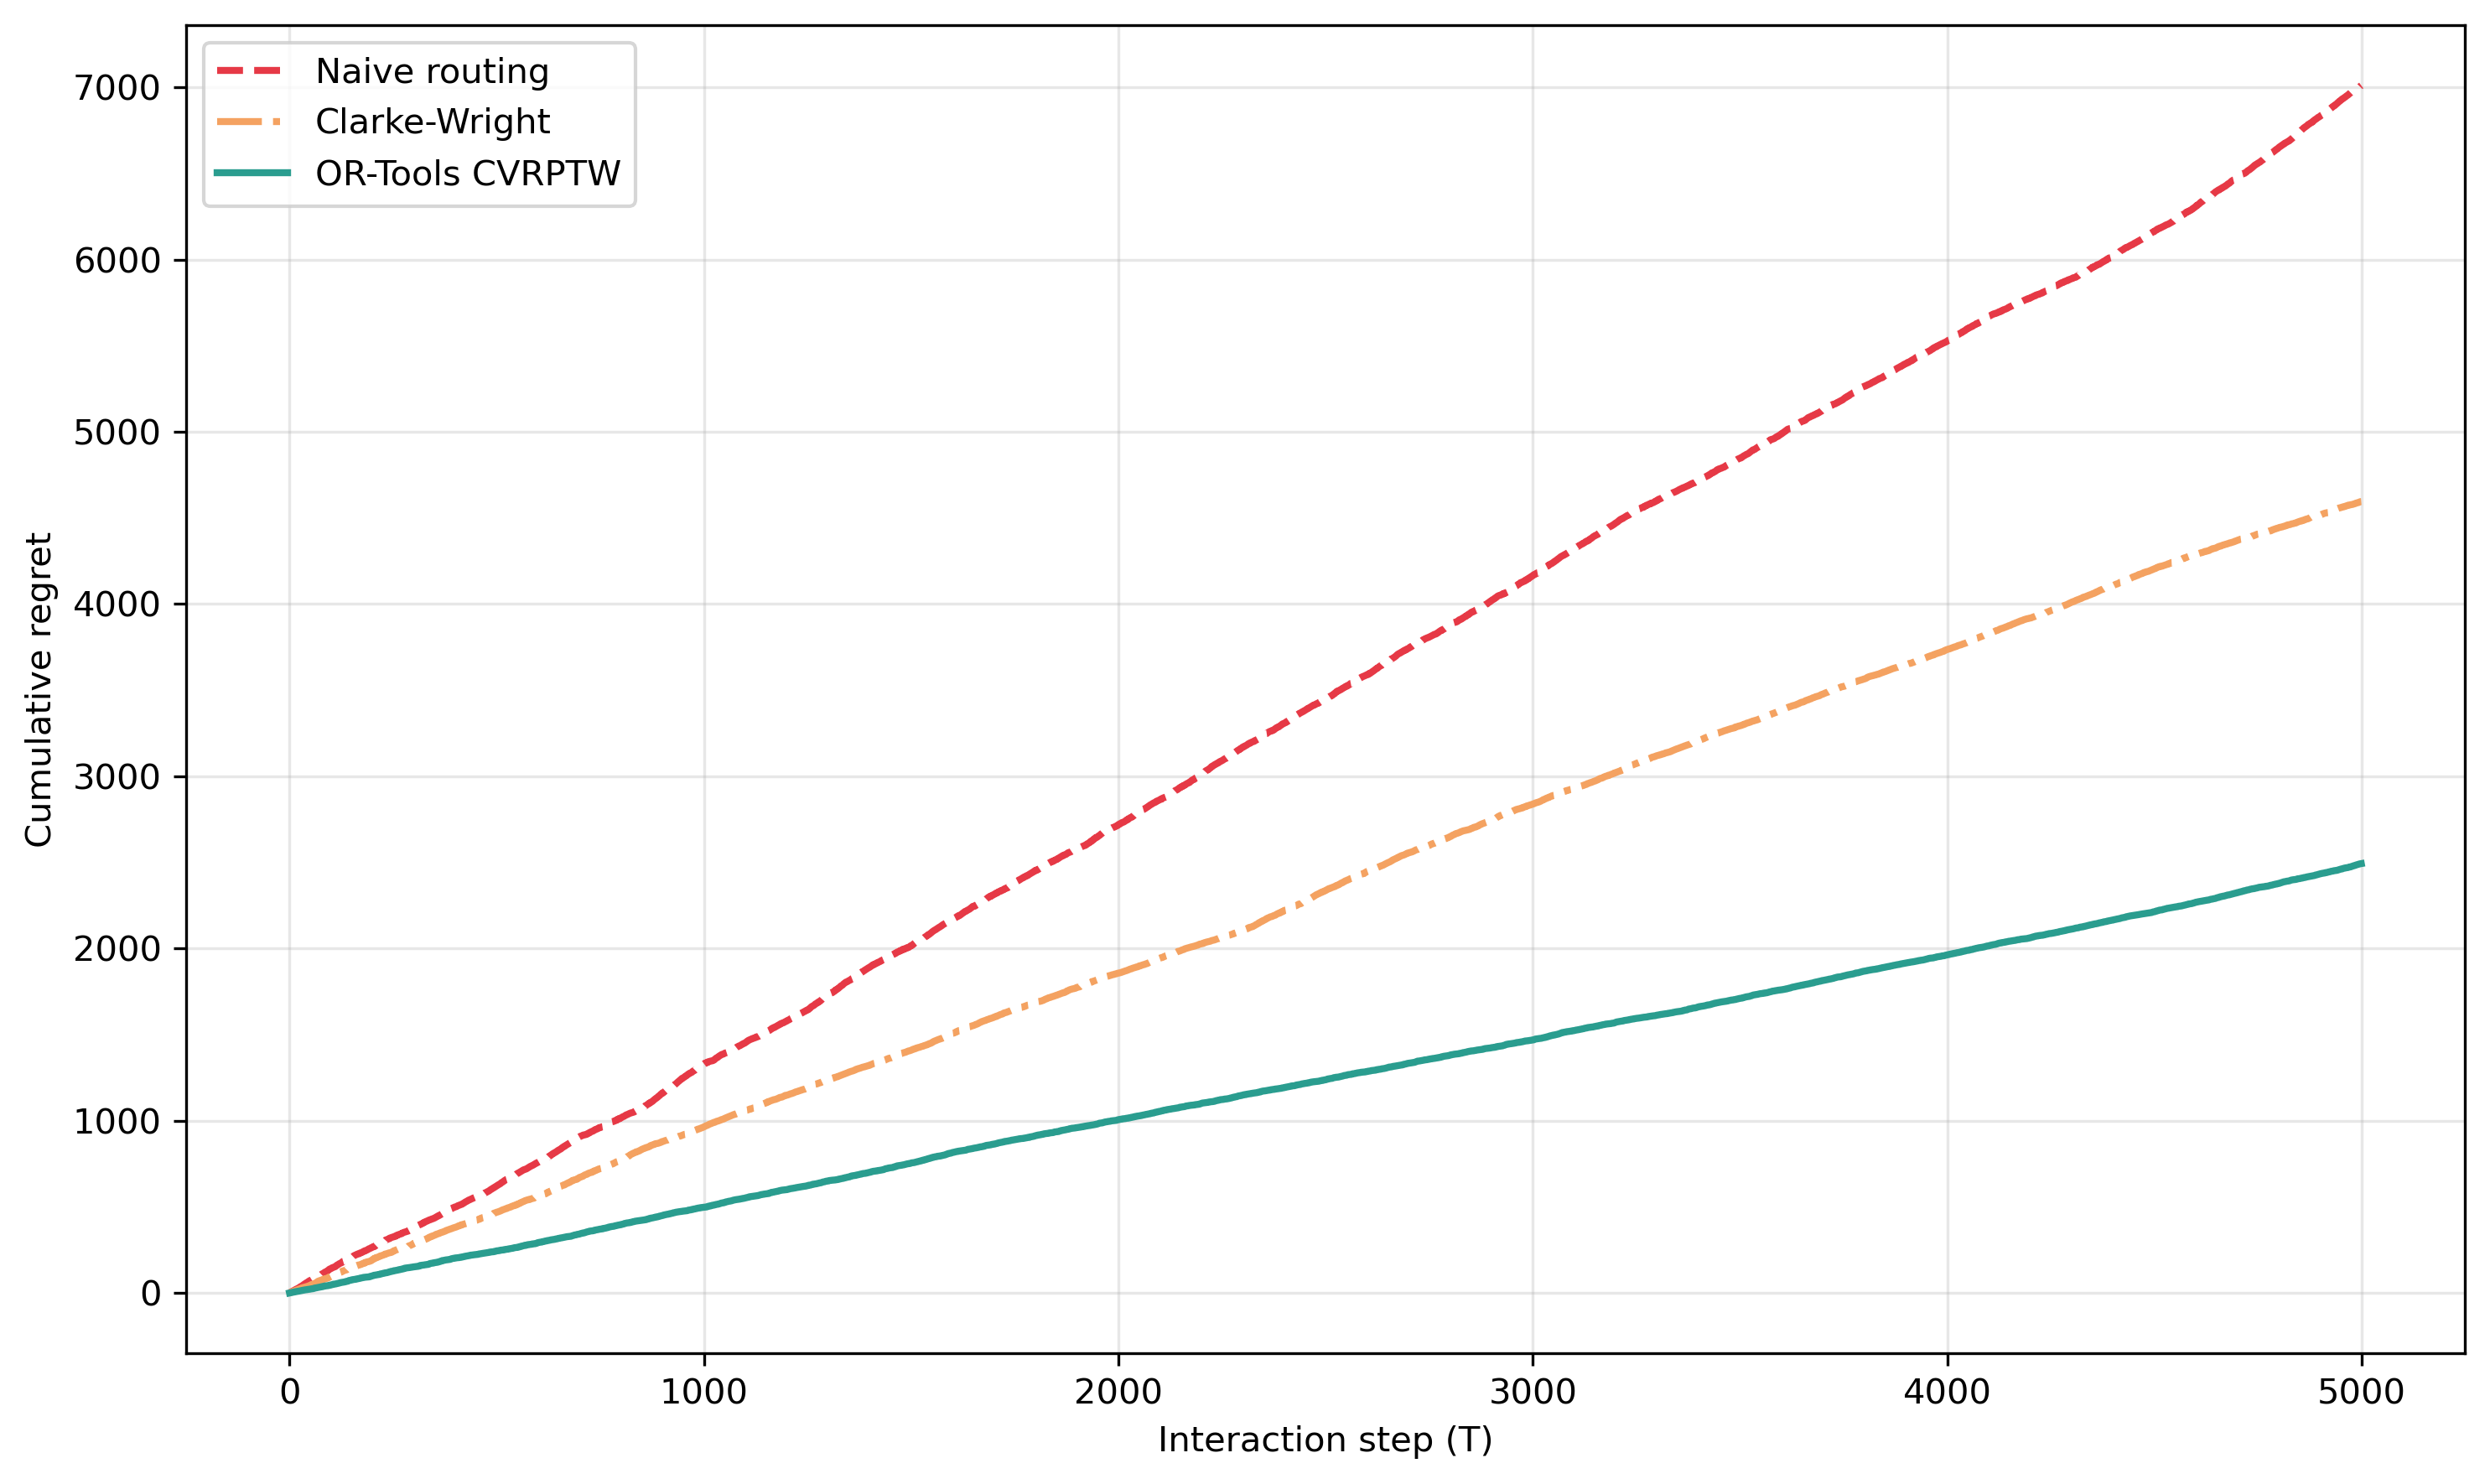

Saved regret_curves.png / .pdf


In [5]:
colors = {'Naive routing': '#e63946', 'Clarke-Wright': '#f4a261', 'OR-Tools CVRPTW': '#2a9d8f'}
styles = {'Naive routing': '--',      'Clarke-Wright': '-.',      'OR-Tools CVRPTW': '-'}

fig, ax = plt.subplots(figsize=(10, 6))
for scenario, result in regret_results.items():
    ax.plot(range(T), result.cumulative_regret,
            label=scenario, color=colors[scenario],
            linestyle=styles[scenario], linewidth=2)

ax.set_xlabel('Interaction step (T)')
ax.set_ylabel('Cumulative regret')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/regret_curves.png', dpi=300, bbox_inches='tight')
plt.savefig('results/regret_curves.pdf', bbox_inches='tight')
plt.show()
print('Saved regret_curves.png / .pdf')

## Cell 6 — Compute coupling coefficient

In [6]:
failure_rates  = np.array([scenarios[s] for s in scenarios])
final_regrets  = np.array([regret_results[s].final_regret for s in scenarios])

# Linear regression: regret = coupling_coeff * failure_rate + intercept
coeffs = np.polyfit(failure_rates, final_regrets, 1)
coupling_coeff = coeffs[0]
intercept      = coeffs[1]

print('Coupling coefficient analysis:')
print(f'  coupling_coeff : {coupling_coeff:.4f}  (regret units per unit failure rate)')
print(f'  intercept      : {intercept:.4f}')
print(f'  R² estimate    : {np.corrcoef(failure_rates, final_regrets)[0,1]**2:.4f}')
print()
print('Interpretation:')
naive_r  = regret_results['Naive routing'].final_regret
ort_r    = regret_results['OR-Tools CVRPTW'].final_regret
reduction = (naive_r - ort_r) / naive_r * 100
print(f'  Switching from naive to OR-Tools CVRPTW routing reduces')
print(f'  LinUCB regret at T={T} by {reduction:.1f}%')
print(f'  This is the thesis Chapter 6 core result.')

Coupling coefficient analysis:
  coupling_coeff : 8065.3327  (regret units per unit failure rate)
  intercept      : 2756.7162
  R² estimate    : 0.8931

Interpretation:
  Switching from naive to OR-Tools CVRPTW routing reduces
  LinUCB regret at T=5000 by 64.4%
  This is the thesis Chapter 6 core result.


## Cell 7 — Lambda ablation: effect of delivery reward weight

  λ=0.0  final_regret=2255.86
  λ=0.1  final_regret=2177.98
  λ=0.2  final_regret=2158.53
  λ=0.3  final_regret=2353.32
  λ=0.4  final_regret=2422.13
  λ=0.5  final_regret=2493.19
  λ=0.6  final_regret=2762.07
  λ=0.7  final_regret=2878.23
  λ=0.8  final_regret=2968.58
  λ=0.9  final_regret=3217.15
  λ=1.0  final_regret=3421.41

Optimal λ: 0.2  (minimises regret at T=5000


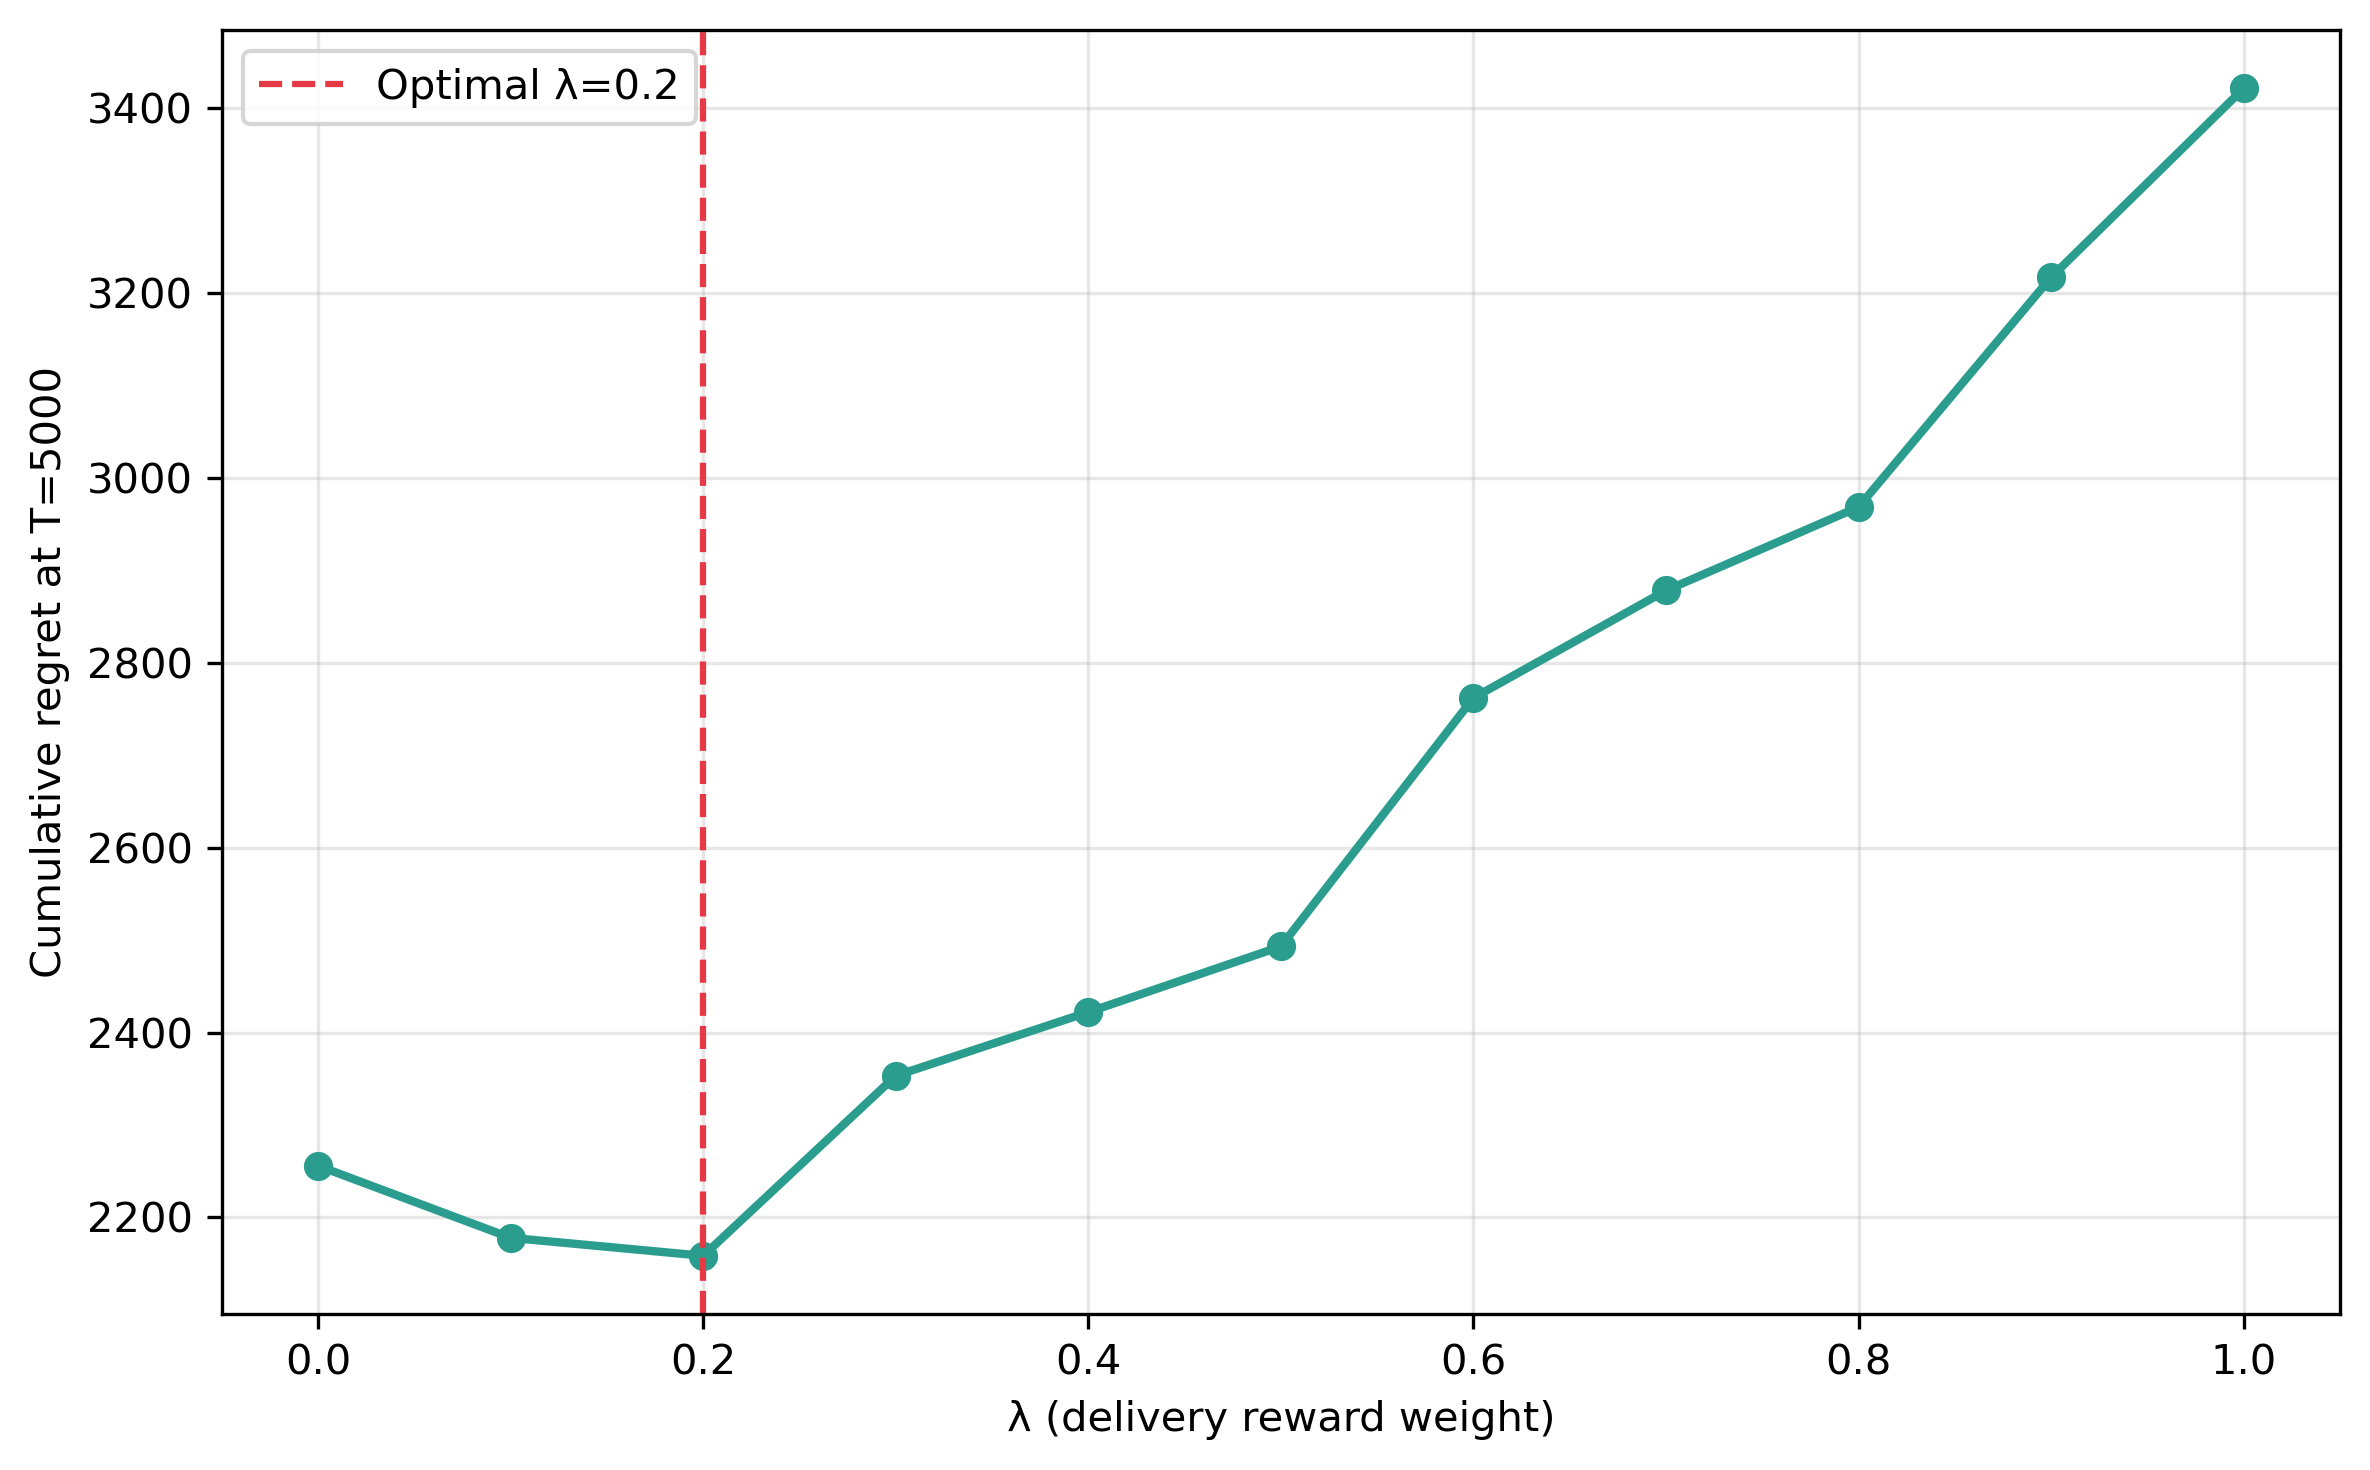

Saved lambda_ablation.png / .pdf


In [7]:
# Use OR-Tools CVRPTW events (best routing quality) for ablation
best_events = delivery_events['OR-Tools CVRPTW']
lambdas     = np.arange(0.0, 1.1, 0.1)
lambda_regrets = []

for lam in lambdas:
    result = compute_linucb_regret(
        reward_events=best_events,
        n_products=50,
        alpha=1.0,
        lam=float(lam),
        T=T,
        seed=42,
    )
    lambda_regrets.append(result.final_regret)
    print(f'  λ={lam:.1f}  final_regret={result.final_regret:.2f}')

optimal_lambda = lambdas[np.argmin(lambda_regrets)]
print(f'\nOptimal λ: {optimal_lambda:.1f}  (minimises regret at T={T}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lambdas, lambda_regrets, 'o-', color='#2a9d8f', linewidth=2)
ax.axvline(optimal_lambda, color='#e63946', linestyle='--',
           label=f'Optimal λ={optimal_lambda:.1f}')
ax.set_xlabel('λ (delivery reward weight)')
ax.set_ylabel(f'Cumulative regret at T={T}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/lambda_ablation.png', dpi=300, bbox_inches='tight')
plt.savefig('results/lambda_ablation.pdf', bbox_inches='tight')
plt.show()
print('Saved lambda_ablation.png / .pdf')

## Cell 8 — Write results CSV and validate

In [8]:
records = []
for scenario in scenarios:
    result = regret_results[scenario]
    records.append({
        'routing_algorithm':  scenario,
        'failure_rate':       round(scenarios[scenario], 4),
        'final_regret_T5000': round(result.final_regret, 4),
        'convergence_step':   result.convergence_step,
        'optimal_lambda':     float(optimal_lambda),
        'coupling_coeff':     round(coupling_coeff, 4),
    })

df_out = pd.DataFrame(records)
csv_path = 'results/rl_reward_impact.csv'
df_out.to_csv(csv_path, index=False)
print(df_out.to_string(index=False))
print(f'\nSaved to {csv_path}')

# Validation
assert os.path.exists(csv_path)
assert os.path.exists('results/regret_curves.png')
assert os.path.exists('results/lambda_ablation.png')

df_check = pd.read_csv(csv_path)
assert len(df_check) == 3, 'Expected 3 rows'

naive_reg = df_check[df_check['routing_algorithm']=='Naive routing']['final_regret_T5000'].values[0]
ort_reg   = df_check[df_check['routing_algorithm']=='OR-Tools CVRPTW']['final_regret_T5000'].values[0]
assert ort_reg < naive_reg, 'OR-Tools CVRPTW must produce lower regret than naive'

print(f'\n✓ OR-Tools regret ({ort_reg:.2f}) < Naive regret ({naive_reg:.2f})')
print('✓ Phase 12 validation passed.')

routing_algorithm  failure_rate  final_regret_T5000  convergence_step  optimal_lambda  coupling_coeff
    Naive routing        0.5432           7010.2935              5000             0.2       8065.3327
    Clarke-Wright        0.1294           4594.8942              5000             0.2       8065.3327
  OR-Tools CVRPTW        0.0500           2493.1917              5000             0.2       8065.3327

Saved to results/rl_reward_impact.csv

✓ OR-Tools regret (2493.19) < Naive regret (7010.29)
✓ Phase 12 validation passed.
